# **GROUP 2 - DSS 740 FINAL PROJECT**

**Group 2:** Samantha Skutnik, David Scott, Thomas Higley, and Jacob Chatten

This project aims to give each student an opportunity to understand how an end-to-end ML project is carried out. Each team will have the opportunity to select a meaningful project to work on. By applying various data pre-processing and machine learning steps, students will be able to build a robust solution consisting of a tuned model.

I am here to help. Feel free to schedule a time with me or email me if you want to discuss ideas or need help. Remember, the objective of this course is to ensure you learn and be successful.

Project Requirements:

1. **Project proposal:** Share a proposal (1 page) in an email by April 12th, 2026. The proposal must describe the project's real-world usefulness (business case) and the technical complexity of solving it. The chosen dataset must have at least 1000 rows and 10 columns. Don't be afraid to select a dataset that contains more data.
2. **Data collection and preprocessing**
    1. Data cleaning (data imputation, outlier treatment, and removing duplicates).
    2. Feature engineering.
    3. Exploratory data analysis to identify interesting patterns and decisions made thereafter.
3. **Model development**
    1. Build and compare several candidate models, such as
        1. **Naive Bayes.**
        2. **Logistic Regression.**
        3. **Decision Tree.**
        4. SVM (Kernel Trick).
        5. RandomForest
        6. XGBoost
    2. Perform hyper-parameter tuning (either using Grid Search or RandomizedSearch CV).
    3. Justify model selection using evaluation metrics (accuracy, precision, recall, F1-score, AUC/ROC).
    4. Address class imbalance.
4. Model interpretation and business insights
    1. Use Partial Dependency Plots or SHAP to explain which factors contribute most to the outcome.


**Deliverables**

1. A well-documented Python class and a Jupyter notebook file with clear and logical steps and outcomes.
2. Technical report (5 - 7 pages)
    1. Problem statement and business case
    2. Data preprocessing steps and actions
    3. Model tuning, selection, and justification
    4. Results and insights
    5. Business implications

In [46]:
# Final Project - Group 2

# install the requirements to get all the packages by typing the following in terminal:
# pip install -r requirements.txt 

# If this doesn't work, check Python version (3.11 or 3.12 normally works best I found) OR
# Just install individual packages: pip install missingno

# Installing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import export_graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

## **Initial Import to Add Features to Dataset**

In [47]:
# # identify folder path
# folder_path = r'C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data'

# identify folder path V2 - relative path
# folder_path = r'..\data'

In [48]:
# # combine yearly datasets into one
# dfs = []

# for root, dirs, files in os.walk(folder_path):
#     for filename in files:
#         file_path = os.path.join(root, filename)
#         if filename.endswith(".xlsx"):
#             print(file_path)
#             df_raw = pd.read_excel(file_path)
#             df_raw['Source'] = filename
#             df_raw['Filepath'] = file_path

#             dfs.append(df_raw)

# df_all = pd.concat(dfs, ignore_index = True)

In [49]:
#df_all.info()

In [50]:
# export to excel
# output = r'C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data\all_incidents_combined.xlsx'
# df_all.to_excel(output, index = False, freeze_panes = (1,0))

## **Load and Explore Dataset**

In [52]:
# Load the data

file = r"..\data\all_incidents_combined.xlsx"
df_original = pd.read_excel(file)
df_original.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng,Source,Filepath
0,NaN,32953,NaN,38492237,18,2,2023-06-07 04:00:00+00,2023-06-07,00:00:00,14.0,202318031155,0 BLOCK IRVING ST,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
1,NaN,32954,NaN,38492238,22,4,2023-07-09 04:00:00+00,2023-07-09,00:00:00,18.0,202322039352,2200 BLOCK CECIL B MOORE A,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 04:00:00+00,2023-04-25,00:00:00,4.0,197935065350,2000 BLOCK 65TH AV,100,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 05:00:00+00,2023-01-19,00:00:00,20.0,202302002459,1600 BLOCK LEVICK ST,100,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 04:00:00+00,2023-07-26,00:00:00,19.0,202317020424,900 BLOCK S 17TH ST,100,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...


In [53]:
df_original.describe().T

,count,mean,min,25%,50%,75%,max,std
cartodb_id,481960.0,2326636.245857,1.0,160223.75,3287768.5,3408717.25,3529207.0,1475288.281407
objectid,481960.0,18196272.352347,96.0,8569044.75,17866839.0,28010682.25,38498485.0,10895389.405756
dc_dist,481960.0,17.454619,1.0,9.0,16.0,24.0,77.0,11.047697
dispatch_date,481960,2024-06-20 11:15:33.567931136,2022-12-31 00:00:00,2023-09-12 00:00:00,2024-06-17 00:00:00,2025-03-29 00:00:00,2025-12-31 00:00:00,NaN
hour,381341.0,13.112464,0.0,9.0,13.0,17.0,23.0,5.68681
dc_key,481960.0,203253304431.106354,197935065350.0,202324002020.75,202415054325.5,202509022347.75,202503028015001.0,412015870727.550293
ucr_general,481960.0,974.754751,100.0,600.0,700.0,1100.0,2600.0,628.356818
point_x,464528.0,1889.869678,-80.502372,-75.184119,-75.156339,-75.115242,2746280.556569,72822.009472
point_y,464528.0,223.970884,0.0,39.958716,39.993153,40.03066,301244.661214,6833.493835
lat,464513.0,39.993612,0.0,39.958687,39.993105,40.030598,42.224336,0.216662


In [54]:
df_original.describe(include='object').T

,count,unique,top,freq
the_geom,464630,231560,0101000020E6100000405E7AC148C452C00F8653499101...,704
the_geom_webmercator,464513,231528,0101000020110F00009DFF04678FE05FC150C65782A291...,704
psa,481831,6,2,156404
dispatch_date_time,481960,394896,2023-12-09 00:49:00+00,15
dispatch_time,481960,2039,00:00:00,1132
location_block,481888,63365,5500 BLOCK TULIP ST,1769
text_general_code,481960,32,Thefts,114365
Source,481960,3,2023 incidents_use.xlsx,169017
Filepath,481960,3,C:\Users\saman\Documents\DSS 740 Machine Learn...,169017


### **Initial Cleaning/Encoding Raw Data**

More Encoding/Preprocessing Later

In [55]:
# Can a copy of the original data frame be made to work with for preprocessing
df_cleaned1 = df_original.copy(deep = True)

In [56]:

df_cleaned1['dc_dist'].value_counts()

dc_dist
15    38374
22    34502
9     32677
24    30937
25    30540
19    28830
14    28513
2     27253
12    26201
35    26116
39    25388
26    21975
18    21209
3     20495
8     19287
16    14973
17    13074
7     11983
1      9538
6      9531
5      7459
77     3104
4         1
Name: count, dtype: int64

In [57]:
# Clean Up District Variable

# Replace a specific district value: change all 6s to 9s
df_cleaned1['dc_dist'] = df_cleaned1['dc_dist'].replace(6, 9)
# https://www.nbcphiladelphia.com/news/local/philadelphia-police-to-merge-6th-and-9th-districts/3846335/#:~:text=The%20Philadelphia%20Police%20Department%20merged%20its%206th,more%20efficiently**%20*%20**Proactively%20police%20high%2Dcrime%20areas**


# Drop rows where district is 4
df = df_cleaned1[df_cleaned1['dc_dist'] != 4]
# https://www.phillypolice.com/district/districts-list/

df_cleaned1['dc_dist'].value_counts()

dc_dist
9     42208
15    38374
22    34502
24    30937
25    30540
19    28830
14    28513
2     27253
12    26201
35    26116
39    25388
26    21975
18    21209
3     20495
8     19287
16    14973
17    13074
7     11983
1      9538
5      7459
77     3104
4         1
Name: count, dtype: int64

In [58]:
# examine data types
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  object        
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [59]:
# make dispatch_date_time a date format & convert from UTC to Eastern tz b/c Philly dataset
df_cleaned1['dispatch_date_time'] = pd.to_datetime(df_cleaned1['dispatch_date_time'], utc= True)

df_cleaned1['dispatch_date_time'] = df_cleaned1['dispatch_date_time'].dt.tz_convert("America/New_York")

df_cleaned1['dispatch_date_time'] = df_cleaned1['dispatch_date_time'].dt.tz_convert("America/New_York").dt.tz_localize(None)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481959 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464629 non-null  object        
 1   cartodb_id            481959 non-null  int64         
 2   the_geom_webmercator  464512 non-null  object        
 3   objectid              481959 non-null  int64         
 4   dc_dist               481959 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481959 non-null  object        
 7   dispatch_date         481959 non-null  datetime64[ns]
 8   dispatch_time         481959 non-null  object        
 9   hour                  381340 non-null  float64       
 10  dc_key                481959 non-null  int64         
 11  location_block        481887 non-null  object        
 12  ucr_general           481959 non-null  int64         
 13  text

In [60]:
# create month col
df_cleaned1['month'] = df_cleaned1['dispatch_date_time'].dt.month

# create day of week col
# 0 = Mon, 1 = Tues, 2 = Wed, 3 = Thurs, 4 = Fri, 5 = Sat, 6 = Sun       - - -    so 5 and 6 would be considered weekends
df_cleaned1['day_of_week'] = df_cleaned1['dispatch_date_time'].dt.dayofweek
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,ucr_general,text_general_code,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,100,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,100,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,100,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2


In [61]:
# create season col
df_cleaned1['season'] = df_cleaned1['month'].map({
    1: "Winter", 2: "Winter", 12: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall", 
})
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,text_general_code,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week,season
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer


In [62]:
# create weekday/weekend col
df_cleaned1['week_type'] = df_cleaned1['day_of_week'].map({
    0: "Weekday", 1: "Weekday", 2: "Weekday", 3: "Weekday", 4: "Weekday",
    5: "Weekend", 6: "Weekend"
})
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week,season,week_type
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer,Weekday
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer,Weekend
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring,Weekday
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter,Weekday
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer,Weekday


In [63]:
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [64]:
# look at stats
df_cleaned1.describe().T

,count,mean,min,25%,50%,75%,max,std
cartodb_id,481960.0,2326636.245857,1.0,160223.75,3287768.5,3408717.25,3529207.0,1475288.281407
objectid,481960.0,18196272.352347,96.0,8569044.75,17866839.0,28010682.25,38498485.0,10895389.405756
dc_dist,481960.0,17.513945,1.0,9.0,16.0,24.0,77.0,10.99395
dispatch_date_time,481960,2024-06-21 00:48:54.207473664,2022-12-31 19:05:00,2023-09-12 15:48:45,2024-06-17 16:58:30,2025-03-29 14:40:00,2025-12-31 18:58:00,NaN
dispatch_date,481960,2024-06-20 11:15:33.567931136,2022-12-31 00:00:00,2023-09-12 00:00:00,2024-06-17 00:00:00,2025-03-29 00:00:00,2025-12-31 00:00:00,NaN
hour,381341.0,13.112464,0.0,9.0,13.0,17.0,23.0,5.68681
dc_key,481960.0,203253304431.106354,197935065350.0,202324002020.75,202415054325.5,202509022347.75,202503028015001.0,412015870727.550293
ucr_general,481960.0,974.754751,100.0,600.0,700.0,1100.0,2600.0,628.356818
point_x,464528.0,1889.869678,-80.502372,-75.184119,-75.156339,-75.115242,2746280.556569,72822.009472
point_y,464528.0,223.970884,0.0,39.958716,39.993153,40.03066,301244.661214,6833.493835


In [65]:
df_cleaned1.describe(include = 'object').T

,count,unique,top,freq
the_geom,464630,231560,0101000020E6100000405E7AC148C452C00F8653499101...,704
the_geom_webmercator,464513,231528,0101000020110F00009DFF04678FE05FC150C65782A291...,704
psa,481831,6,2,156404
dispatch_time,481960,2039,00:00:00,1132
location_block,481888,63365,5500 BLOCK TULIP ST,1769
text_general_code,481960,32,Thefts,114365
Source,481960,3,2023 incidents_use.xlsx,169017
Filepath,481960,3,C:\Users\saman\Documents\DSS 740 Machine Learn...,169017
season,481960,4,Summer,132304
week_type,481960,2,Weekday,362699


In [66]:
df_cleaned1['text_general_code'].value_counts()

text_general_code
Thefts                                     114365
Other Assaults                              80021
Motor Vehicle Theft                         51747
Vandalism/Criminal Mischief                 44110
All Other Offenses                          44083
Theft from Vehicle                          33607
Fraud                                       25282
Aggravated Assault No Firearm               16152
Burglary Residential                        10384
Aggravated Assault Firearm                   8380
Weapon Violations                            8247
Narcotic / Drug Law Violations               8017
Robbery No Firearm                           7531
Robbery Firearm                              5533
Burglary Non-Residential                     4823
Receiving Stolen Property                    3929
Other Sex Offenses (Not Commercialized)      3309
DRIVING UNDER THE INFLUENCE                  2566
Arson                                        1988
Disorderly Conduct              

<Axes: ylabel='text_general_code'>

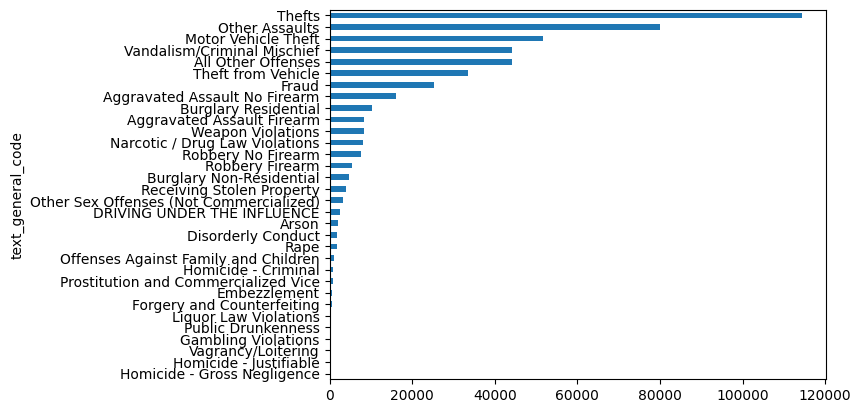

In [67]:
# look at crime type distribution
df_cleaned1['text_general_code'].value_counts().sort_values(ascending = True).plot(kind = 'barh')

array([[<Axes: title={'center': 'cartodb_id'}>,
        <Axes: title={'center': 'objectid'}>,
        <Axes: title={'center': 'dc_dist'}>,
        <Axes: title={'center': 'dispatch_date_time'}>],
       [<Axes: title={'center': 'dispatch_date'}>,
        <Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'dc_key'}>,
        <Axes: title={'center': 'ucr_general'}>],
       [<Axes: title={'center': 'point_x'}>,
        <Axes: title={'center': 'point_y'}>,
        <Axes: title={'center': 'lat'}>, <Axes: title={'center': 'lng'}>],
       [<Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'day_of_week'}>, <Axes: >, <Axes: >]],
      dtype=object)

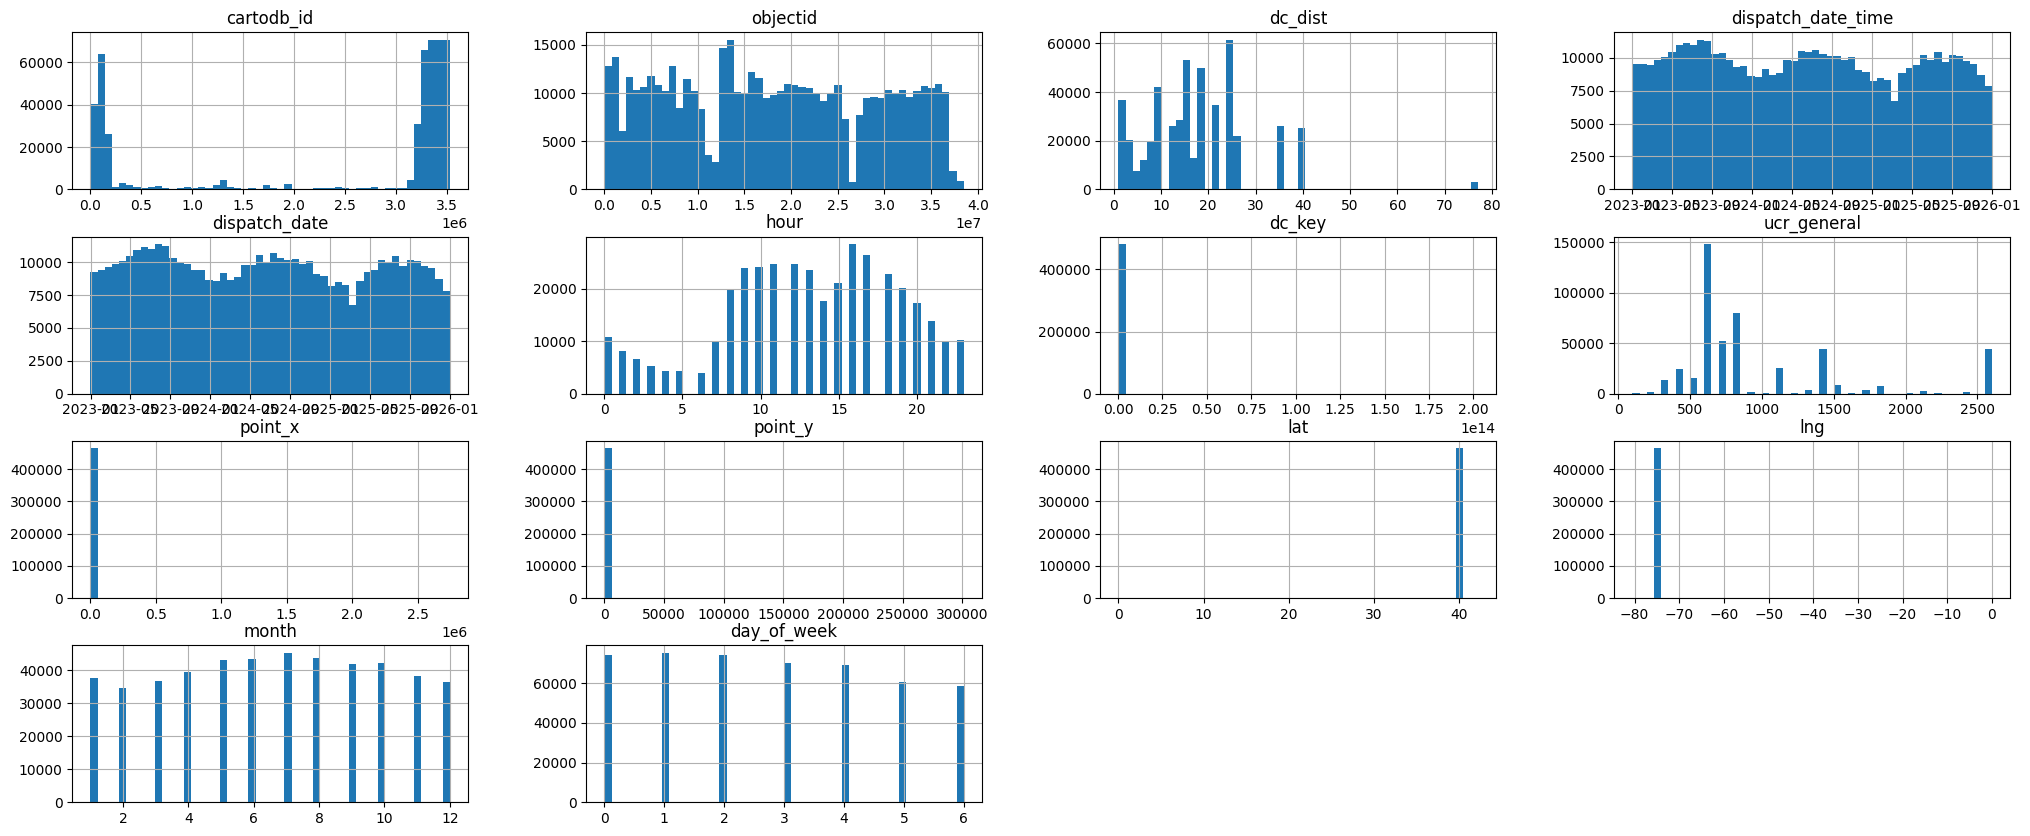

In [68]:
df_cleaned1.hist(bins = 50, figsize = (25, 10))

In [69]:
# classify crime types as violent or not and map text_general_codes
df_cleaned1['text_general_code'] = df_cleaned1['text_general_code'].str.lower().str.strip()

crime_mapping = {
    key.lower(): value for key, value in {
"Aggravated Assault Firearm":1,
"Aggravated Assault No Firearm":1,
"All Other Offenses":0,
"Arson":1,
"Burglary Non-Residential":1,
"Burglary Residential":1,
"Disorderly Conduct":0,
"DRIVING UNDER THE INFLUENCE":0,
"Embezzlement":0,
"Forgery and Counterfeiting":0,
"Fraud":0,
"Gambling Violations":0,
"Homicide - Criminal":1,
"Homicide - Gross Negligence":1,
"Homicide - Justifiable":1,
"Liquor Law Violations":0,
"Motor Vehicle Theft":0,
"Narcotic / Drug Law Violations":0,
"Offenses Against Family and Children":1,
"Other Assaults":1,
"Other Sex Offenses (Not Commercialized)":1,
"Prostitution and Commercialized Vice":0,
"Public Drunkenness":0,
"Rape":1,
"Receiving Stolen Property":0,
"Robbery Firearm":1,
"Robbery No Firearm":1,
"Theft from Vehicle":0,
"Thefts":0,
"Vagrancy/Loitering":0,
"Vandalism/Criminal Mischief":0,
"Weapon Violations":0,
}.items()}

df_cleaned1['violent_crime'] = df_cleaned1['text_general_code'].map(crime_mapping)
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,point_y,lat,lng,Source,Filepath,month,day_of_week,season,week_type,violent_crime
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer,Weekday,1
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer,Weekend,1
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring,Weekday,1
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter,Weekday,1
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer,Weekday,1


In [70]:
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [71]:
''' notes to group:
I dont think we need hour if we're using date_time

Do we need point_x and point_y?? there are 17,400 missing values for point x and y not including incorrect numbers (0, etc.)

Do we need lat and long? there are 17,447 missing values

not sure if we need the_geom or the_geom_webmercator

do we need psa? It's "A single character field that names the Police Service Area boundary"

'''

df_cleaned1.isnull().sum().sort_values(ascending = False)

hour                    100619
lat                      17447
lng                      17447
the_geom_webmercator     17447
point_x                  17432
point_y                  17432
the_geom                 17330
psa                        129
location_block              72
dispatch_time                0
dispatch_date                0
dispatch_date_time           0
dc_dist                      0
cartodb_id                   0
objectid                     0
ucr_general                  0
dc_key                       0
text_general_code            0
Source                       0
Filepath                     0
month                        0
day_of_week                  0
season                       0
week_type                    0
violent_crime                0
dtype: int64

In [72]:
# remove any columns we dont need

''' 
thoughts about dropping the below columns ??? - should we also drop dc_dist and dc_key? it would give us 11 cols which is still OK per the project outline

DC_Dist	District	A two character field that names the District boundary.	Text
DC_Key	DC Number	The unique identifier of the crime that consists of Year + District + Unique ID.

'''

# cols_to_drop = ['the_geom', 'cartodb_id', 'the_geom_webmercator', 'dispatch_date', 'dispatch_time', 'hour', 'point_x', 'point_y', 'lat', 'lng', 'Source', 'Filepath']
# df = df.drop(columns = cols_to_drop)

' \nthoughts about dropping the below columns ??? - should we also drop dc_dist and dc_key? it would give us 11 cols which is still OK per the project outline\n\nDC_Dist\tDistrict\tA two character field that names the District boundary.\tText\nDC_Key\tDC Number\tThe unique identifier of the crime that consists of Year + District + Unique ID.\n\n'

In [73]:
# DROP UNNECESSARY COLUMNS
# Remove any that you think are necessary

df_cleaned1 = df_cleaned1.drop(columns=['hour','the_geom_webmercator', 'lng', 'lat', 'point_x', 'point_y', 'the_geom', 'psa', 'cartodb_id','objectid', 'dc_key', 
                      'dispatch_time', 'dispatch_date', 'Source', 'Filepath', 'location_block' ])

In [74]:
df_cleaned1.isnull().sum().sort_values(ascending = False)

dc_dist               0
dispatch_date_time    0
ucr_general           0
text_general_code     0
month                 0
day_of_week           0
season                0
week_type             0
violent_crime         0
dtype: int64

In [75]:
# Copy to use for each demo

df1 = df_cleaned1.copy(deep = True)
df2 = df_cleaned1.copy(deep = True)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481959 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464629 non-null  object        
 1   cartodb_id            481959 non-null  int64         
 2   the_geom_webmercator  464512 non-null  object        
 3   objectid              481959 non-null  int64         
 4   dc_dist               481959 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481959 non-null  object        
 7   dispatch_date         481959 non-null  datetime64[ns]
 8   dispatch_time         481959 non-null  object        
 9   hour                  381340 non-null  float64       
 10  dc_key                481959 non-null  int64         
 11  location_block        481887 non-null  object        
 12  ucr_general           481959 non-null  int64         
 13  text

## **Code Below to Create Response Variable**

Need to check over this cause I needed the AI's help a lot with this 

### **Demo 1** (without Years and can only have 672 rows)
I like Demo 2 better this is here so you can see it too and it helped me understand this process better

In [77]:
# DEMO 1 is WITHOUT YEAR  (see DEMO 2 next instead for)
# NOTE: with this capped at 672 possible rows (21 districts × 4 seasons × 2 week types × 4 times of day) which he wants 1000 rows
# Therefore, I think we should include year, Demo 2, though the crime rate treshold is a little bit more weird 



"""
Crime Prediction - Creating the Response Variable
==================================================
This script takes a raw list of crime incidents and transforms it into
a structured dataset with a binary response variable (High vs Low Crime)
suitable for machine learning models like Decision Tree, Logistic Regression,
and Naive Bayes.
 
Columns used:
    dc_dist             - Police district (21 districts, 1-2 digit numbers)
    dispatch_date_time  - Full datetime of the incident
    month               - Month (1–12)
    day_of_week         - Day of week (1–7)
    week_type           - 'Weekday' or 'Weekend'
    season              - 'Winter', 'Spring', 'Summer', 'Fall'
    violent_crime       - 1 = violent crime, 0 = non-violent
"""
 

# Ensure datetime column is parsed correctly
df1['dispatch_date_time'] = pd.to_datetime(df1['dispatch_date_time'])
 
 
# ── 2. CLEAN THE DISTRICT COLUMN ─────────────────────────────────────────────
# Drop any rows with unexpected/invalid district values if needed
# df = df[df['dc_dist'] != 4]          # Example: remove district 4
# df['dc_dist'] = df['dc_dist'].replace(6, 9)  # Example: recode 6 → 9
 
 
# ── 3. ADD TIME OF DAY FROM dispatch_date_time ───────────────────────────────
# Bin the hour into four buckets since crime patterns are non-linear across hours
df1['time_of_day'] = df1['dispatch_date_time'].dt.hour.map(
    lambda h: 'Morning'   if 6  <= h < 12
    else      'Afternoon' if 12 <= h < 17
    else      'Evening'   if 17 <= h < 21
    else      'Night'
)
 
 
# ── 4. NORMALIZE FOR TIME BIAS ───────────────────────────────────────────────
# There are 5 weekdays but only 2 weekend days, and seasons vary in length.
# Using raw crime counts would unfairly inflate counts for longer periods.
# We normalize by dividing by the number of actual days in each group
# to get a crimes-per-day RATE instead of a raw count.
 
# Count unique dates per week_type (how many actual Weekdays vs Weekend days)
week_type_day_counts = (
    df1.groupby('week_type')['dispatch_date_time']
    .apply(lambda x: x.dt.date.nunique())
    .reset_index(name='num_days_week_type')
)
 
# Count unique dates per season
season_day_counts = (
    df1.groupby('season')['dispatch_date_time']
    .apply(lambda x: x.dt.date.nunique())
    .reset_index(name='num_days_season')
)
 
 
# ── 5. AGGREGATE INTO ONE ROW PER SCENARIO ───────────────────────────────────
# Each row represents a unique combination of conditions
# e.g. District 3 + Summer + Weekend + Evening → crime count
aggregated = (
    df1.groupby(['dc_dist', 'season', 'week_type', 'time_of_day'])
    .size()
    .reset_index(name='crime_count')
)
 
# Merge in day counts so we can normalize
aggregated = aggregated.merge(week_type_day_counts, on='week_type')
aggregated = aggregated.merge(season_day_counts, on='season')
 
# Compute crimes per day (normalized — fair comparison across all groups)
aggregated['crime_rate'] = aggregated['crime_count'] / aggregated['num_days_week_type']
 
 
# ── 6. CREATE THE BINARY RESPONSE VARIABLE ───────────────────────────────────
# Use the median crime rate as the threshold.
# At or above median → 1 (High Crime)
# Below median       → 0 (Low Crime)
# The median ensures a roughly balanced split between classes.
# to represent only the most extreme areas.

# threshold = aggregated['crime_rate'].median()  # This is that code, I switched it to below

# Swap to aggregated['crime_rate'].quantile(0.75) if you want High Crime
# Top 25% = High Crime, bottom 75% = Low Crime
threshold = aggregated['crime_rate'].quantile(0.75)
 
aggregated['crime_label'] = aggregated['crime_rate'].apply(
    lambda x: 1 if x >= threshold else 0
)
 
print(f"Threshold (Top 75% crime rate): {threshold:.2f}")
print(f"High Crime rows: {aggregated['crime_label'].sum()}")
print(f"Low Crime rows:  {(aggregated['crime_label'] == 0).sum()}")
 
 
# ── 7. PREPARE FINAL DATASET FOR MODELING ────────────────────────────────────
# Drop intermediate count/rate columns — the model only needs features + label.
# Keeping crime_count or crime_rate would be "cheating" since the label
# was derived directly from them.
 
model1_df = aggregated[['dc_dist', 'season', 'week_type', 'time_of_day', 'crime_label']]
 
# X = feature columns (inputs to the model)
X = model1_df[['dc_dist', 'season', 'week_type', 'time_of_day']]
 
# y = response variable (what the model learns to predict)
y = model1_df['crime_label']
 
print("\nFinal dataset demo 1 sample:")
print(model1_df.head(10))
 

Threshold (Top 75% crime rate): 1.64
High Crime rows: 169
Low Crime rows:  504

Final dataset demo 1 sample:
   dc_dist  season week_type time_of_day  crime_label
0        1    Fall   Weekday   Afternoon            0
1        1    Fall   Weekday     Evening            0
2        1    Fall   Weekday     Morning            0
3        1    Fall   Weekday       Night            0
4        1    Fall   Weekend   Afternoon            0
5        1    Fall   Weekend     Evening            0
6        1    Fall   Weekend     Morning            0
7        1    Fall   Weekend       Night            0
8        1  Spring   Weekday   Afternoon            0
9        1  Spring   Weekday     Evening            0


### **Demo 2** (with Years and more than 1000+ rows)

In [78]:
# DEMO 2 is WITH YEAR
# we are NOT capped at 672 possible rows (21 districts × 4 seasons × 2 week types × 4 times of day) and we are already over 1000
# NOTE: the threshold crime rates in this one is much lower (though for both demos it was top 25% high and bottom 75% low) - just noting this, no necessarily a problem
# I don't know if this is a problem or not, both demos it was top 25% high and bottom 75% low

"""
Crime Prediction - Creating the Response Variable
==================================================
This script takes a raw list of crime incidents and transforms it into
a structured dataset with a binary response variable (High vs Low Crime)
suitable for machine learning models like Decision Tree, Logistic Regression,
and Naive Bayes.
 
Columns used:
    dc_dist             - Police district (21 districts, 1-2 digit numbers)
    dispatch_date_time  - Full datetime of the incident
    month               - Month (1–12)
    day_of_week         - Day of week (1–7)
    week_type           - 'Weekday' or 'Weekend'
    season              - 'Winter', 'Spring', 'Summer', 'Fall'
    violent_crime       - 1 = violent crime, 0 = non-violent
"""
  
# Ensure datetime column is parsed correctly
df2['dispatch_date_time'] = pd.to_datetime(df2['dispatch_date_time'])
 
 
# ── 1. CLEAN THE DISTRICT COLUMN ─────────────────────────────────────────────
# Drop any rows with unexpected/invalid district values if needed
# df = df[df['dc_dist'] != 4]          # Example: remove district 4
# df['dc_dist'] = df['dc_dist'].replace(6, 9)  # Example: recode 6 → 9
 
 
# ── 2. ENGINEER FEATURES FROM dispatch_date_time ─────────────────────────────
# Extract year (useful for seeing if districts shift over time,
# but note classifiers won't automatically detect trends — they treat
# year as a category, not a sequence)
df2['year'] = df2['dispatch_date_time'].dt.year
 
# Bin the hour into four buckets since crime patterns are non-linear across hours
df2['time_of_day'] = df2['dispatch_date_time'].dt.hour.map(
    lambda h: 'Morning'   if 6  <= h < 12
    else      'Afternoon' if 12 <= h < 17
    else      'Evening'   if 17 <= h < 21
    else      'Night'
)
 
 
# ── 3. NORMALIZE FOR TIME BIAS ───────────────────────────────────────────────
# There are 5 weekdays but only 2 weekend days, and seasons vary in length.
# Using raw crime counts would unfairly inflate counts for longer periods.
# We normalize by dividing by the number of actual days in each group
# to get a crimes-per-day RATE instead of a raw count.
 
# Count unique dates per week_type (how many actual Weekdays vs Weekend days)
week_type_day_counts = (
    df2.groupby('week_type')['dispatch_date_time']
    .apply(lambda x: x.dt.date.nunique())
    .reset_index(name='num_days_week_type')
)
 
# Count unique dates per season
season_day_counts = (
    df2.groupby('season')['dispatch_date_time']
    .apply(lambda x: x.dt.date.nunique())
    .reset_index(name='num_days_season')
)
 
 
# ── 4. AGGREGATE INTO ONE ROW PER SCENARIO ───────────────────────────────────
# Each row represents a unique combination of conditions
# e.g. District 3 + Summer + Weekend + Evening + 2022 → crime count
 
# Total crime count per scenario
aggregated = (
    df2.groupby(['dc_dist', 'year', 'season', 'week_type', 'time_of_day'])
    .size()
    .reset_index(name='crime_count')
)
 
# Proportion of violent crimes per scenario
# (mean of 0s and 1s gives the rate, e.g. 0.4 = 40% of crimes were violent)
violent = (
    df2.groupby(['dc_dist', 'year', 'season', 'week_type', 'time_of_day'])['violent_crime']
    .mean()
    .reset_index(name='violent_crime_rate')
)
 
# Merge violent crime rate into the aggregated dataset
aggregated = aggregated.merge(
    violent, on=['dc_dist', 'year', 'season', 'week_type', 'time_of_day']
)
 
# Merge in day counts for normalization
aggregated = aggregated.merge(week_type_day_counts, on='week_type')
aggregated = aggregated.merge(season_day_counts, on='season')
 
# Compute crimes per day (normalized — fair comparison across all groups)
aggregated['crime_rate'] = aggregated['crime_count'] / aggregated['num_days_week_type']
 
 
# ── 5. CREATE THE BINARY RESPONSE VARIABLE ───────────────────────────────────
# Top 25% of crime rates → 1 (High Crime)
# Bottom 75%             → 0 (Low Crime)
# NOTE: This creates a class imbalance (75% Low, 25% High). Use F1-score
# or AUC to evaluate models — not plain accuracy — since a model that always
# predicts Low Crime would still be "75% accurate" without learning anything.
 
threshold = aggregated['crime_rate'].quantile(0.75)
 
aggregated['crime_label'] = aggregated['crime_rate'].apply(
    lambda x: 1 if x >= threshold else 0
)
 
print(f"Threshold (75th percentile crime rate): {threshold:.2f}")
print(f"High Crime rows: {aggregated['crime_label'].sum()}")
print(f"Low Crime rows:  {(aggregated['crime_label'] == 0).sum()}")
 
 
# ── 6. PREPARE FINAL DATASET FOR MODELING ────────────────────────────────────
# Drop intermediate count/rate columns — the model only needs features + label.
# Keeping crime_count or crime_rate would be "cheating" since the label
# was derived directly from them.
 
model_df2 = aggregated[[
    'dc_dist', 'year', 'season', 'week_type', 'time_of_day',
    'violent_crime_rate', 'crime_label'
]]
 
# X = feature columns (inputs to the model)
X = model_df2[['dc_dist', 'year', 'season', 'week_type', 'time_of_day', 'violent_crime_rate']]
 
# y = response variable (what the model learns to predict)
y = model_df2['crime_label']
 
print("\nFinal dataset sample:")
print(model_df2.head(10))


Threshold (75th percentile crime rate): 0.55
High Crime rows: 513
Low Crime rows:  1536

Final dataset sample:
   dc_dist  year  season week_type time_of_day  violent_crime_rate  \
0        1  2022  Winter   Weekend       Night            0.000000   
1        1  2023    Fall   Weekday   Afternoon            0.197115   
2        1  2023    Fall   Weekday     Evening            0.217742   
3        1  2023    Fall   Weekday     Morning            0.217647   
4        1  2023    Fall   Weekday       Night            0.340206   
5        1  2023    Fall   Weekend   Afternoon            0.301587   
6        1  2023    Fall   Weekend     Evening            0.333333   
7        1  2023    Fall   Weekend     Morning            0.325581   
8        1  2023    Fall   Weekend       Night            0.365854   
9        1  2023  Spring   Weekday   Afternoon            0.265700   

   crime_label  
0            0  
1            0  
2            0  
3            0  
4            0  
5            0  

### I didn't look at below this yet, this is mostly what we had below already

In [ ]:
#cat_cols = df.select_dtypes(include = ['object']).columns
#print(cat_cols)

''' this part takes a while to run '''

# for col in cat_cols:
#     plt.figure(figsize = (4,4))

#     sns.countplot(data = df, x = col)

#     plt.show()


In [ ]:
#df['dispatch_time'].head()

In [ ]:
#df.info()

In [ ]:
# explore numerical columns
# num_cols = df.select_dtypes(include = [np.number]).columns
# corr_matrix = df[num_cols].corr()
# np.round(corr_matrix[''].sort_values(ascending = False), 4)

In [ ]:
# sns.pairplot(df[num_cols])
# plt.show()

In [ ]:
# # look at heatmap to see correlation between features 
# plt.figure(figsize=(12,8))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, mask=mask)
# plt.title('Correlation Matrix Heatmap')
# plt.show()

In [ ]:
# encode categorical cols

''' this is failing - I'm having memory issues because its trying to encode all cat cols which includes location which has a LOT of unique values... also i think its trying to encode the id col.. this may be a problem... thoughts?! '''

#df = pd.get_dummies(df, columns = cat_cols, drop_first = True, dtype = int)

#df.info()
#df

In [ ]:
# need to split data into training and testing - pass in your x matrix and the y value - then talk about how much data do you want to keep to test 
# (train model on diff dataset and predict on unseen data)

# drop target col and make y = target col

''' is target violent crime?? '''

#X = df.drop('violent_crime', axis = 1)

#y = df['violent_crime']

# split the data
# X_train = df w trainings features
# X_test = df w test features

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y,)

In [ ]:
# scale data
#scaler = StandardScaler()

#X_train_scaled = scaler.fit_transform(X_train)   # array
#X_test_scaled = scaler.transform(X_test)         # array

In [ ]:
# create logistic regression model

#lr_model = LogisticRegression(max_iter = 1000)
#lr_model.fit(X_train_scaled, y_train)
#y_pred = lr_model.predict(X_test_scaled)

In [ ]:
#look at confusion matrix
#cm = confusion_matrix(y_test, y_pred)
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#plt.xlabel('Predicted')
#plt.ylabel('True')
#plt.title(f'Confusion Matrix for Logistic Regression')
#plt.show()

# __ true negatives (predicted no _____ and actually no ______)
# __ false positives (predicted _____ but actually no _____)
# __ false negatives (predicted _____ but they actually had _____) **
# __ true positives (predicted _____ and actually had _____)

In [ ]:
# evaulate LR model - calc accuracy, precision, recall, f1
#accuracy = accuracy_score(y_test, y_pred)
#precision = precision_score(y_test, y_pred)
#recall = recall_score(y_test, y_pred)
#specificity = cm[0,0] / (cm[0,0] + cm[0,1])
#f1 = f1_score(y_test, y_pred)
#print(f'Logistic Regression Model Performance:')
#print(f'Accuracy: {accuracy:.4f}')
#print(f'Precision: {precision:.4f}')
#print(f'Recall: {recall:.4f}')
#print(f'Specificity: {specificity:.4f}')
#print(f'F1-score: {f1:.4f}')